<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module2_Lab1_Geometric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Geometric Transformations & Image Processing (Labs)
**Computer Vision**

Runs in Google Colab or local Jupyter. Images are loaded in **color** and displayed via Matplotlib with a proper **BGR→RGB** conversion, so colours are always correct. Sections follow the Module 2 doc: geometric transforms & arithmetic, intensity/contrast, smoothing & denoising, colour spaces & edges, and image pyramids.

## Setup
Run first. Loads your image (or a synthetic colour image if none is found) and defines display helpers.

In [ ]:
# Optional (Colab): read images from your Drive
from google.colab import drive; drive.mount('/content/drive')
from pathlib import Path
import cv2, numpy as np
import matplotlib.pyplot as plt

shape: (512, 512, 3) | dtype: uint8


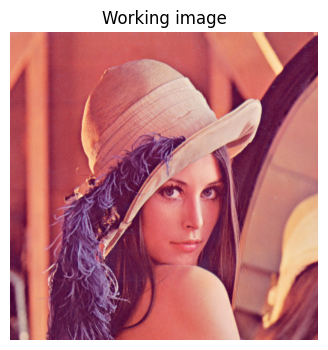

In [ ]:
FOLDER   = "/content/drive/MyDrive/cv_images/"   # change if needed
IMG_FILE = "Lenna.png"     # change to your image
img_path = Path(FOLDER) / IMG_FILE

def load_color(p):
    """Load in color (BGR). Returns None on failure (always check!)."""
    return cv2.imread(str(p), cv2.IMREAD_COLOR)

def make_demo(h=360, w=480):
    """Synthetic colour image so the labs run without your own file."""
    im = np.full((h, w, 3), 240, np.uint8)
    cv2.rectangle(im, (30, 40),  (180, 200), (0, 0, 200), -1)    # red   (BGR)
    cv2.circle(im,    (330, 110), 70,         (0, 160, 0),  -1)  # green
    cv2.rectangle(im, (250, 230), (430, 320), (200, 60, 0), -1)  # blue
    cv2.circle(im,    (120, 290), 45,         (0, 200, 200), -1) # yellow
    cv2.putText(im, "CV", (200, 150), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (40,40,40), 4, cv2.LINE_AA)
    return im

img = load_color(img_path)
if img is None:
    print("[warn] Could not load your image — using a synthetic demo. Edit FOLDER/IMG_FILE to use your own.")
    img = make_demo()
print("shape:", img.shape, "| dtype:", img.dtype)

def show(bgr, title="", cmap=None):
    plt.figure(figsize=(4,4))
    if bgr.ndim == 2: plt.imshow(bgr, cmap=cmap or "gray", vmin=0, vmax=255)
    else:             plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

def show_row(items, cmap=None):
    """items = list of (image, title). Displays them side by side."""
    n=len(items); plt.figure(figsize=(3.2*n, 3.3))
    for i,(im,t) in enumerate(items):
        ax=plt.subplot(1,n,i+1)
        if im.ndim==2: ax.imshow(im, cmap=cmap or "gray", vmin=0, vmax=255)
        else:          ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()

show(img, "Working image")

## 2.1 Geometric Transformations
### Scaling / resizing
`INTER_CUBIC` is good for enlarging; `INTER_AREA` is best for shrinking.

orig (512, 512, 3) | up (1024, 1024, 3) | down (256, 256, 3)


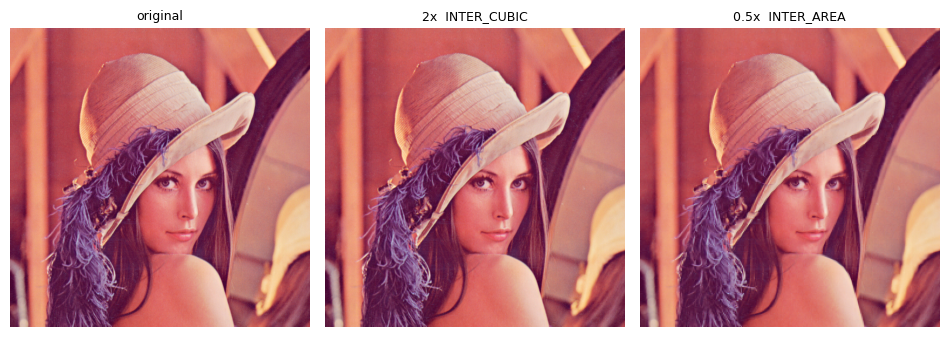

In [ ]:
h, w = img.shape[:2]
up   = cv2.resize(img, (w*2, h*2), interpolation=cv2.INTER_CUBIC)
down = cv2.resize(img, (w//2, h//2), interpolation=cv2.INTER_AREA)
print("orig", img.shape, "| up", up.shape, "| down", down.shape)
show_row([(img,"original"), (up,"2x  INTER_CUBIC"), (down,"0.5x  INTER_AREA")])

### Rotation
`getRotationMatrix2D(center, angle, scale)` — a **positive angle rotates counter-clockwise** (OpenCV convention).

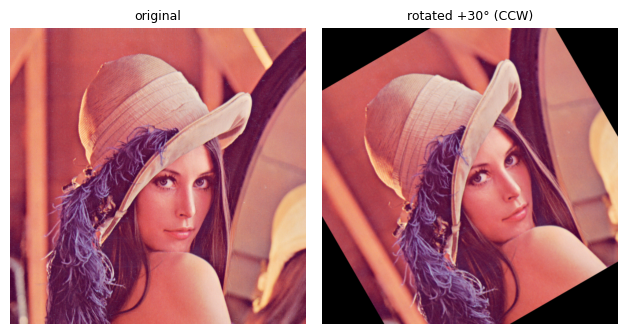

In [ ]:
h, w = img.shape[:2]
M   = cv2.getRotationMatrix2D((w//2, h//2), 30, 1.0)   # +30° = counter-clockwise
rot = cv2.warpAffine(img, M, (w, h))
show_row([(img,"original"), (rot,"rotated +30° (CCW)")])

### Translation
Shift by (tx, ty) using a 2×3 matrix `[[1,0,tx],[0,1,ty]]`.

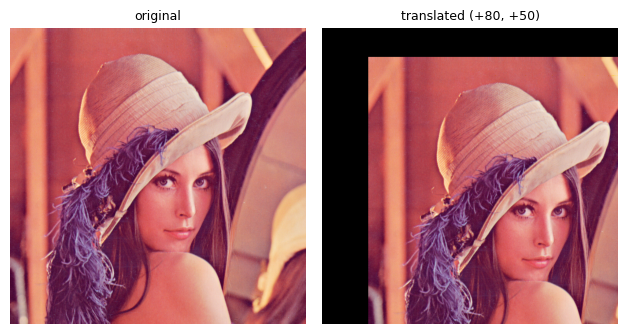

In [ ]:
tx, ty = 80, 50
M = np.float32([[1, 0, tx], [0, 1, ty]])
trans = cv2.warpAffine(img, M, (w, h))
show_row([(img,"original"), (trans,f"translated (+{tx}, +{ty})")])

### Shearing
Skew along an axis with an off-diagonal term; widen the canvas so nothing is clipped.

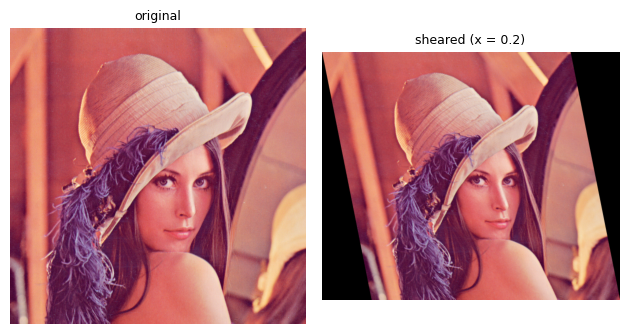

In [ ]:
shx = 0.2
M = np.float32([[1, shx, 0], [0, 1, 0]])
shear = cv2.warpAffine(img, M, (int(w + shx*h), h))
show_row([(img,"original"), (shear,"sheared (x = 0.2)")])

### Flipping
`cv2.flip(src, flipCode)` — 1 = horizontal, 0 = vertical, -1 = both.

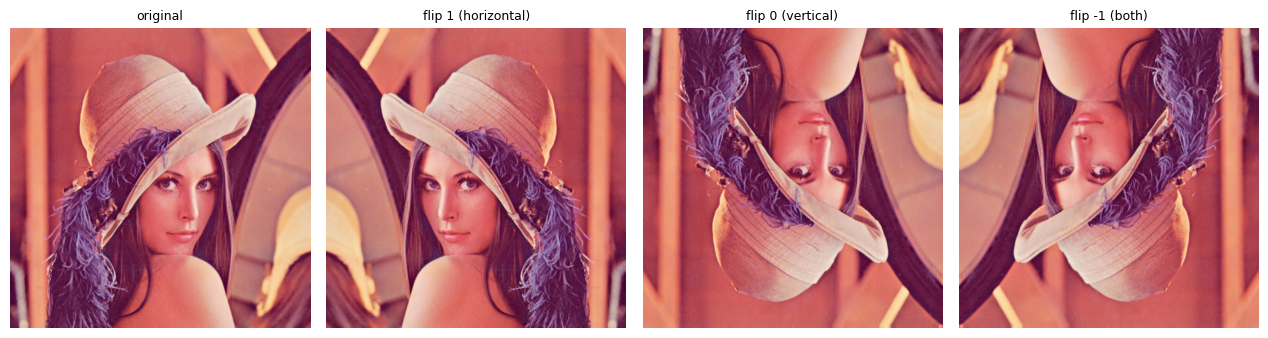

In [ ]:
show_row([(img,"original"),
          (cv2.flip(img, 1), "flip 1 (horizontal)"),
          (cv2.flip(img, 0), "flip 0 (vertical)"),
          (cv2.flip(img,-1), "flip -1 (both)")])

### Cropping / ROI extraction
An image is a NumPy array, so cropping is slicing `[y1:y2, x1:x2]`. Use `.copy()` for an independent crop.

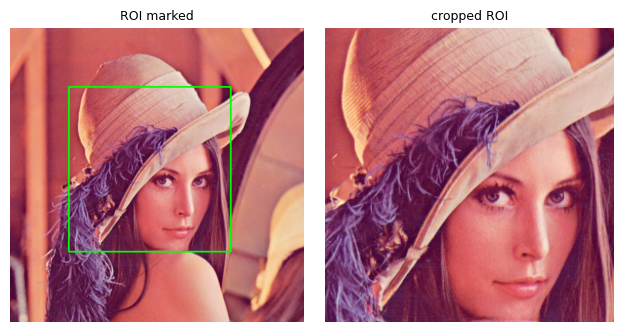

In [ ]:
h, w = img.shape[:2]
x1,y1,x2,y2 = int(0.2*w), int(0.2*h), int(0.75*w), int(0.76*h)
roi = img[y1:y2, x1:x2].copy()
marked = img.copy(); cv2.rectangle(marked, (x1,y1), (x2,y2), (0,255,0), 2)
show_row([(marked,"ROI marked"), (roi,"cropped ROI")])

### Image arithmetic & blending
OpenCV arithmetic **saturates** (clips to 0–255). `addWeighted` cross-fades two images; bitwise ops composite through masks.

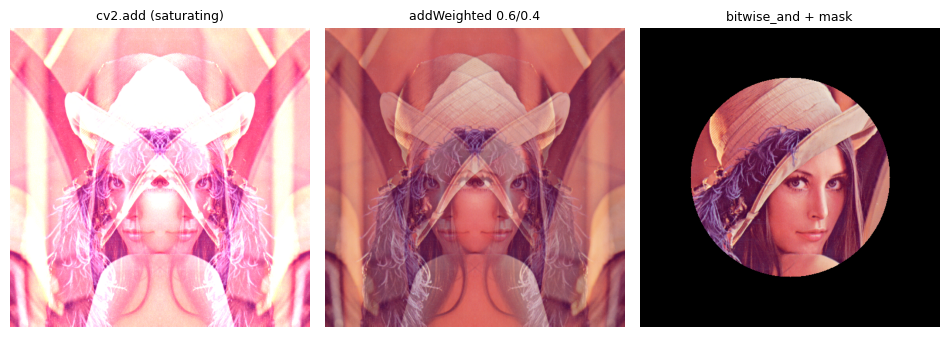

In [ ]:
img2 = cv2.flip(img, 1)
added   = cv2.add(img, img2)                        # saturating add
blended = cv2.addWeighted(img, 0.6, img2, 0.4, 0)   # 0.6*img + 0.4*img2
mask = np.zeros(img.shape[:2], np.uint8)
cv2.circle(mask, (w//2, h//2), min(h,w)//3, 255, -1)
masked = cv2.bitwise_and(img, img, mask=mask)
show_row([(added,"cv2.add (saturating)"), (blended,"addWeighted 0.6/0.4"), (masked,"bitwise_and + mask")])

## 2.2 Intensity & Contrast Transformations

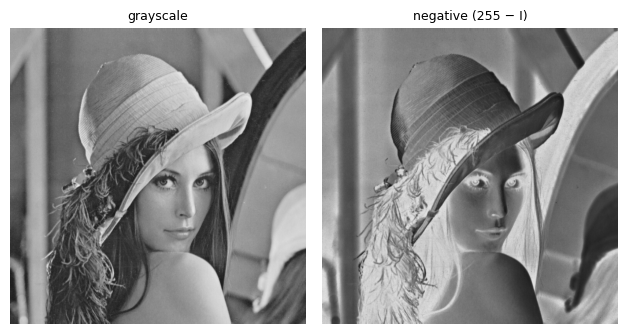

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
neg  = 255 - gray                                   # image negative
show_row([(gray,"grayscale"), (neg,"negative (255 − I)")])

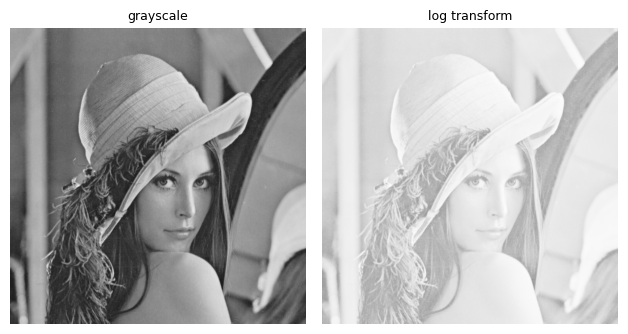

In [ ]:
# Log transform:  s = c * log(1 + r)
c = 255 / np.log(1 + gray.max())
log_t = (c * np.log(1 + gray.astype(np.float32))).astype(np.uint8)
show_row([(gray,"grayscale"), (log_t,"log transform")])

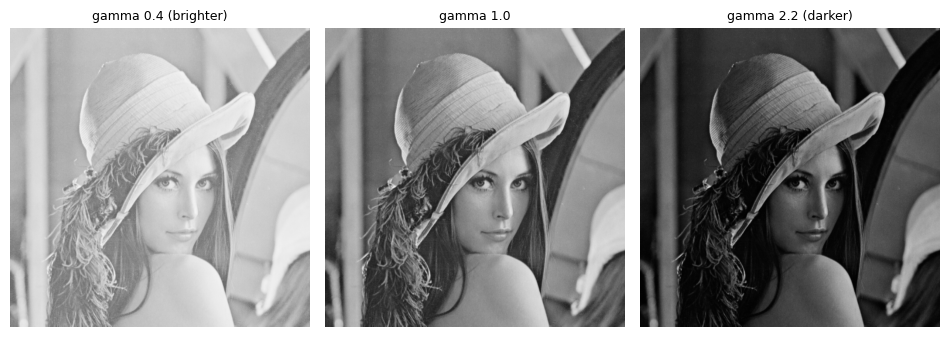

In [ ]:
# Power-law (gamma):  s = 255 * (r/255) ** gamma
def gamma_correct(im, g): return np.array(255*(im/255.0)**g, dtype=np.uint8)
show_row([(gamma_correct(gray,0.4),"gamma 0.4 (brighter)"),
          (gray,"gamma 1.0"),
          (gamma_correct(gray,2.2),"gamma 2.2 (darker)")])

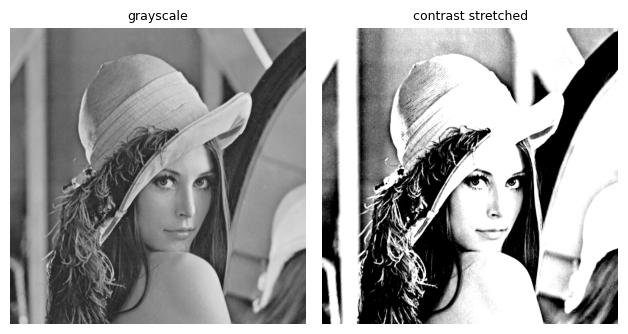

In [ ]:
# Contrast stretching (piecewise-linear), vectorized
def contrast_stretch(im, r1, s1, r2, s2):
    x = im.astype(np.float32); out = np.zeros_like(x)
    m1 = x <= r1; m2 = (x > r1) & (x <= r2); m3 = x > r2
    out[m1] = (s1/r1) * x[m1]
    out[m2] = ((s2-s1)/(r2-r1)) * (x[m2]-r1) + s1
    out[m3] = ((255-s2)/(255-r2)) * (x[m3]-r2) + s2
    return np.clip(out, 0, 255).astype(np.uint8)
cs = contrast_stretch(gray, 70, 0, 140, 255)
show_row([(gray,"grayscale"), (cs,"contrast stretched")])

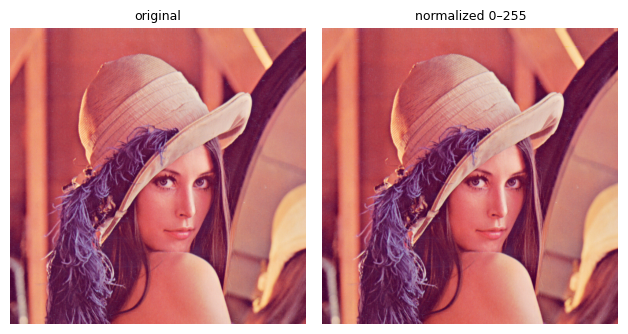

In [ ]:
# Normalization: NORM_MINMAX rescales to a chosen [min,max] range
norm = cv2.normalize(img.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show_row([(img,"original"), (norm,"normalized 0–255")])

## 2.3 Smoothing, Blurring & Denoising

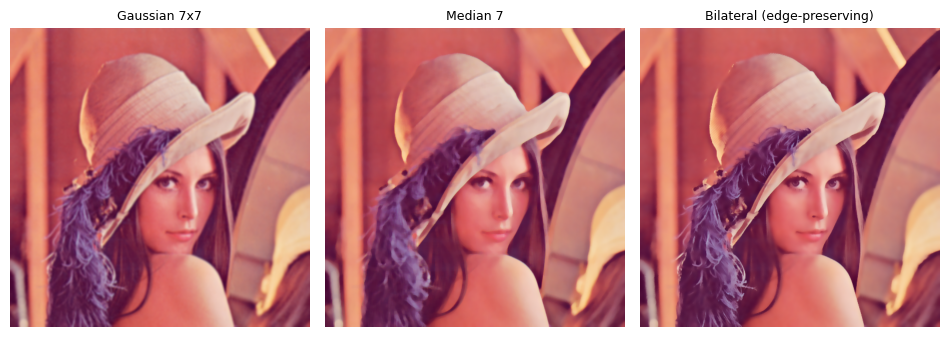

In [ ]:
g = cv2.GaussianBlur(img, (7,7), 0)
m = cv2.medianBlur(img, 7)
b = cv2.bilateralFilter(img, 9, 75, 75)   # edge-preserving
show_row([(g,"Gaussian 7x7"), (m,"Median 7"), (b,"Bilateral (edge-preserving)")])

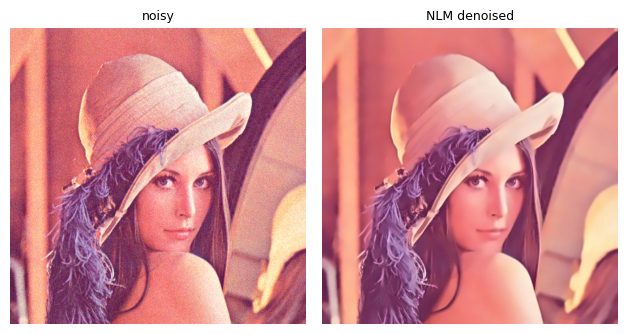

In [ ]:
# Add random noise, then denoise with Non-Local Means
noise = np.random.randint(0, 50, img.shape, dtype=np.uint8)
noisy = cv2.add(img, noise)
den   = cv2.fastNlMeansDenoisingColored(noisy, None, 10, 10, 7, 15)
show_row([(noisy,"noisy"), (den,"NLM denoised")])

## 2.4 Colour Spaces & Edge Detection

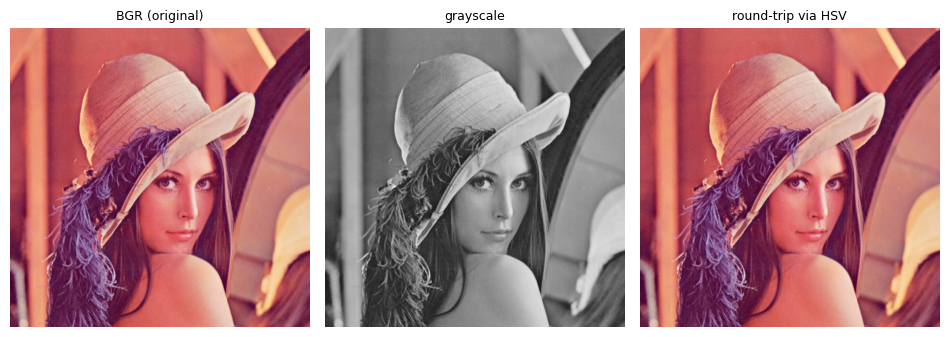

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
show_row([(img,"BGR (original)"), (gray,"grayscale"),
          (cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR),"round-trip via HSV")])

### Colour filtering in HSV
Thresholding a hue range isolates a colour — here, blue.

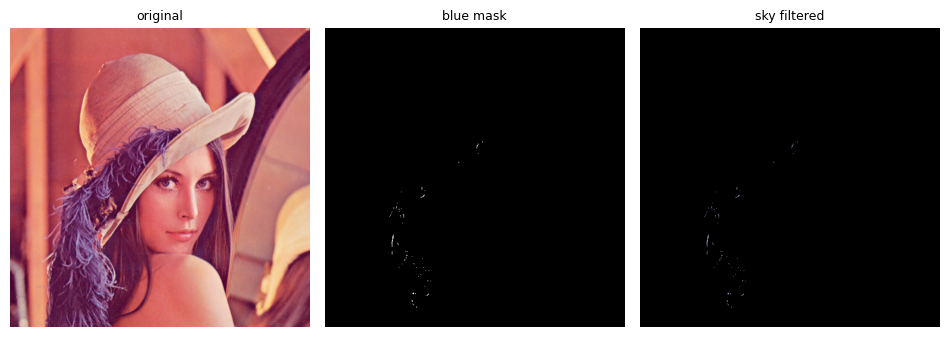

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Widened to catch the pale blue sky behind the lion
lower = np.array([90, 20, 80]); upper = np.array([130, 255, 255])
mask = cv2.inRange(hsv, lower, upper)
result = cv2.bitwise_and(img, img, mask=mask)
show_row([(img,"original"), (mask,"blue mask"), (result,"sky filtered")])

### Canny edge detection
Run on the **grayscale** image with sensible thresholds.

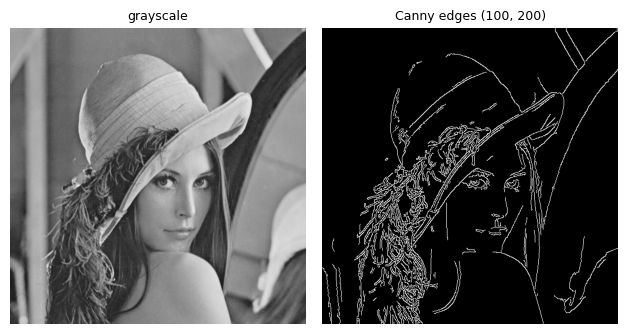

In [ ]:
edges = cv2.Canny(gray, 100, 200)
show_row([(gray,"grayscale"), (edges,"Canny edges (100, 200)")])

## 2.5 Image Pyramids
`pyrDown` halves resolution (Gaussian pyramid); `pyrUp` doubles it. A Laplacian level = a Gaussian level minus an upsampled coarser level.

Gaussian pyramid sizes: [(512, 512), (256, 256), (128, 128), (64, 64)]


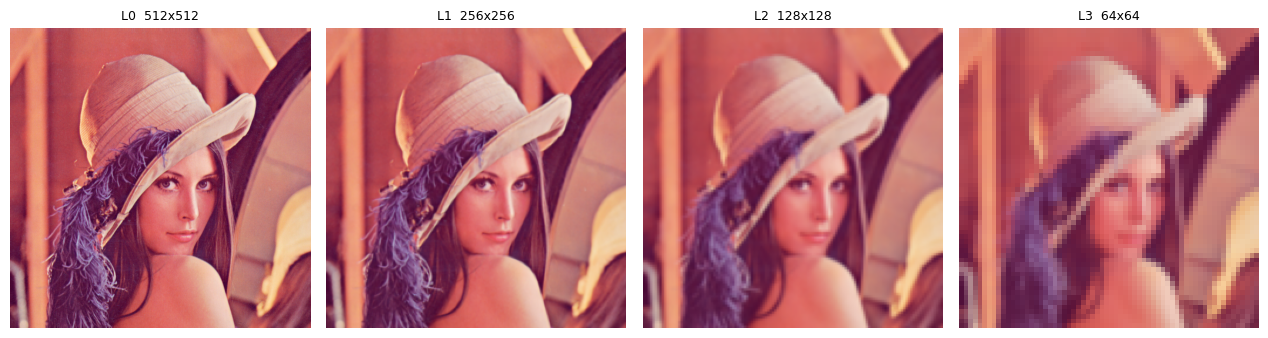

In [ ]:
g = img.copy(); gp = [g]
for _ in range(3):
    g = cv2.pyrDown(g); gp.append(g)
print("Gaussian pyramid sizes:", [p.shape[:2] for p in gp])
show_row([(p, f"L{i}  {p.shape[1]}x{p.shape[0]}") for i,p in enumerate(gp)])

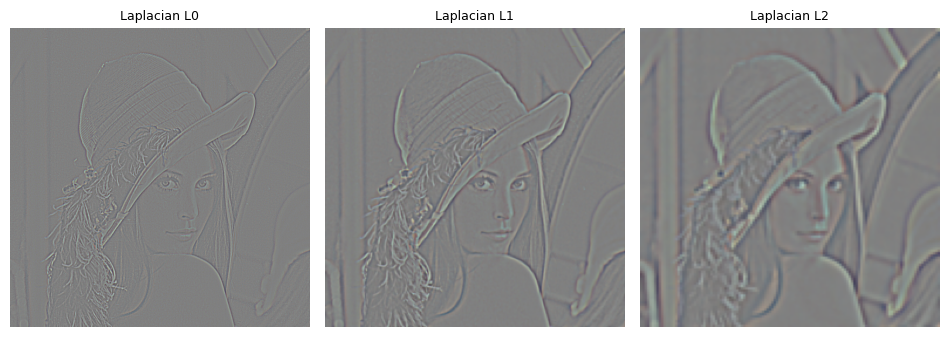

In [ ]:
lap = []
for i in range(len(gp)-1):
    up = cv2.pyrUp(gp[i+1], dstsize=(gp[i].shape[1], gp[i].shape[0]))
    # Use CV_16S to allow negative differences without clipping to 0!
    diff = cv2.subtract(gp[i], up, dtype=cv2.CV_16S)
    lap.append(diff)

# Use beta=128 to shift the zero-point to middle gray so edges are visible
show_row([(cv2.convertScaleAbs(l, alpha=1.0, beta=128), f"Laplacian L{i}") for i,l in enumerate(lap)])